<a href="https://colab.research.google.com/github/syntheticbeek/bravo-departure-model/blob/main/BRAVO_DEPARTURE_MODEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

── Training Dataset ──
            cast_member  gender  betrayal_index  victim_narrative_index  \
0       Denise Richards       0             8.0                       8   
1         Raquel Leviss       0            10.0                       8   
2        Olivia Flowers       0             6.5                       7   
3      Taylor Ann Green       0             8.0                       9   
4         Kyle Richards       0             5.0                       8   
5          Tom Sandoval       1            10.0                       1   
6          Austen Kroll       1             7.0                       1   
7  Whitney Sudler-Smith       1             6.0                       3   

   outcome  
0        1  
1        1  
2        1  
3        1  
4        0  
5        0  
6        0  
7        0  

── Variable Weights ──
              Variable    Weight
victim_narrative_index  0.785028
        betrayal_index  0.610436
             confirmed  0.218178
        prior_incident  0.20

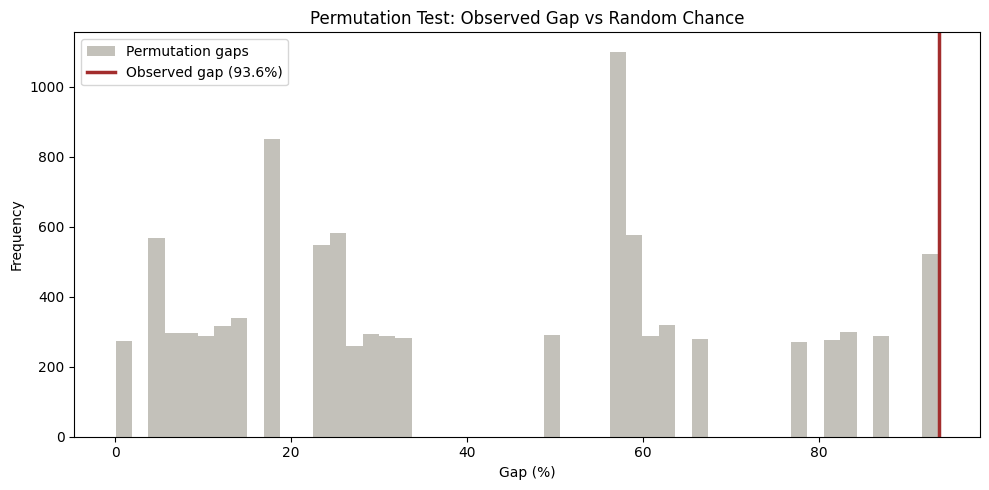

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Training Dataset ──────────────────────────────────────────────────────────
data = {
    'cast_member': [
        'Denise Richards', 'Raquel Leviss', 'Olivia Flowers',
        'Taylor Ann Green', 'Kyle Richards',
        'Tom Sandoval', 'Austen Kroll', 'Whitney Sudler-Smith'
    ],
    'show': [
        'RHOBH', 'VPR', 'Southern Charm',
        'Southern Charm', 'RHOBH',
        'VPR', 'Southern Charm', 'Southern Charm'
    ],
    'trigger_timing': [
        'mid', 'late', 'early',
        'early', 'early',
        'late', 'early', 'mid'
    ],
    'confirmed':              [0, 0, 1, 0, 0, 1, 0, 0],
    'cast_reaction':          [2, 2, 1, 2, 1, 2, 1, 1],
    'betrayal_index':         [8, 10, 6.5, 8, 5, 10, 7, 6],
    'narrative_equity':       [7, 7, 7, 8, 10, 10, 8, 5],
    'victim_narrative_index': [8, 8, 7, 9, 8, 1, 1, 3],
    'prior_incident':         [0, 0, 1, 0, 0, 1, 1, 0],
    'gender':                 [0, 0, 0, 0, 0, 1, 1, 1],  # 0=woman 1=man
    'outcome':                [1, 1, 1, 1, 0, 0, 0, 0]   # 1=exited 0=stayed
}

df = pd.DataFrame(data)

timing_map = {'early': 0, 'mid': 1, 'late': 2, 'after_filming': 3}
df['trigger_timing_encoded'] = df['trigger_timing'].map(timing_map)

print('── Training Dataset ──')
print(df[['cast_member', 'gender', 'betrayal_index', 'victim_narrative_index', 'outcome']])

features = [
    'trigger_timing_encoded', 'confirmed', 'cast_reaction',
    'betrayal_index', 'narrative_equity', 'victim_narrative_index',
    'prior_incident', 'gender'
]

X_train = df[features]
y_train = df['outcome']

model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# ── Variable Weights ──────────────────────────────────────────────────────────
print('\n── Variable Weights ──')
weights = pd.DataFrame({
    'Variable': features,
    'Weight': model.coef_[0]
}).sort_values('Weight', ascending=False)
print(weights.to_string(index=False))

# ── Test Cases: Amanda and West ───────────────────────────────────────────────
test_data = {
    'cast_member':            ['Amanda', 'West'],
    'trigger_timing_encoded': [3, 3],
    'confirmed':              [0, 0],
    'cast_reaction':          [2, 2],
    'betrayal_index':         [10, 6],
    'narrative_equity':       [10, 8],
    'victim_narrative_index': [10, 3],
    'prior_incident':         [0, 1],   # West = 1 (Ciara breakup)
    'gender':                 [0, 1]    # Amanda=woman West=man
}

test_df = pd.DataFrame(test_data)
predictions = model.predict_proba(test_df[features])

print('\n── Predictions ──')
for i, name in enumerate(['Amanda', 'West']):
    print(f'{name} — Exit probability: {predictions[i][1]:.1%}')

# ── Ablation Analysis ─────────────────────────────────────────────────────────
def run_ablation(drop_feature, label, amanda_input, west_input):
    feats = [f for f in features if f != drop_feature]
    m = LogisticRegression(random_state=42)
    m.fit(df[feats], df['outcome'])
    test = pd.DataFrame([amanda_input, west_input])
    preds = m.predict_proba(test[feats])
    print(f'\n── Without {label} ──')
    for i, name in enumerate(['Amanda', 'West']):
        print(f'{name} — Exit probability: {preds[i][1]:.1%}')
    print(f'Gap without {label}: {abs(preds[0][1] - preds[1][1]):.1%}')
    return abs(preds[0][1] - preds[1][1])

amanda_base = {
    'trigger_timing_encoded': 3, 'confirmed': 0, 'cast_reaction': 2,
    'betrayal_index': 10, 'narrative_equity': 10,
    'victim_narrative_index': 10, 'prior_incident': 0, 'gender': 0
}
west_base = {
    'trigger_timing_encoded': 3, 'confirmed': 0, 'cast_reaction': 2,
    'betrayal_index': 6, 'narrative_equity': 8,
    'victim_narrative_index': 3, 'prior_incident': 1, 'gender': 1
}

victim_gap   = run_ablation('victim_narrative_index', 'Victim Narrative', amanda_base, west_base)
betrayal_gap = run_ablation('betrayal_index',         'Betrayal Index',   amanda_base, west_base)
gender_gap   = run_ablation('gender',                 'Gender',           amanda_base, west_base)

full_gap = abs(predictions[0][1] - predictions[1][1])

print(f'\n── Summary: Gap Under Each Condition ──')
print(f'Full model (all variables):     {full_gap:.1%}')
print(f'Without gender:                 {gender_gap:.1%}')
print(f'Without betrayal index:         {betrayal_gap:.1%}')
print(f'Without victim narrative:       {victim_gap:.1%}')
print(f'\nKey insight: removing victim narrative collapses the gap by {full_gap - victim_gap:.1%} points.')
print(f'It is not what you did. It is who the audience thought you were.')

# ── Permutation Test ──────────────────────────────────────────────────────────
print('\n── Permutation Test: Could the gap occur by chance? ──')

observed_gap = abs(predictions[0][1] - predictions[1][1])
print(f'Observed gap: {observed_gap:.1%}')

n_permutations = 10000
permutation_gaps = []

for seed in range(n_permutations):
    rng = np.random.RandomState(seed)
    y_permuted = rng.permutation(y_train)
    if len(np.unique(y_permuted)) < 2:
        continue
    m = LogisticRegression(random_state=42, max_iter=1000)
    m.fit(X_train, y_permuted)
    p = m.predict_proba(test_df[features])
    permutation_gaps.append(abs(p[0][1] - p[1][1]))

permutation_gaps = np.array(permutation_gaps)
p_value = (permutation_gaps >= observed_gap).mean()

print(f'Permutations completed: {len(permutation_gaps)}/{n_permutations}')
print(f'Mean permutation gap: {permutation_gaps.mean():.1%}')
print(f'Max permutation gap: {permutation_gaps.max():.1%}')
print(f'Permutations >= observed gap: {(permutation_gaps >= observed_gap).sum()}')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print(f'\nResult: SIGNIFICANT — the observed gap is unlikely to occur by chance (p={p_value:.4f})')
elif p_value < 0.10:
    print(f'\nResult: MARGINAL — borderline significance (p={p_value:.4f})')
else:
    print(f'\nResult: NOT SIGNIFICANT — the gap could occur by chance (p={p_value:.4f})')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(permutation_gaps * 100, bins=50, color='#B4B2A9', alpha=0.8, label='Permutation gaps')
ax.axvline(observed_gap * 100, color='#A32D2D', linewidth=2.5, label=f'Observed gap ({observed_gap:.1%})')
ax.set_xlabel('Gap (%)')
ax.set_ylabel('Frequency')
ax.set_title('Permutation Test: Observed Gap vs Random Chance')
ax.legend()
plt.tight_layout()
plt.show()